# Training an Inverse Model and Computing Predictions

This tutorial follows the **README example** of `ncpi` and explicitly includes both stages: training an inference model and computing predictions of the ground-truth E/I ratio from synthetic LFP signals and `catch22` features.

In addition, we train and compare **multiple machine-learning regressors** instead of using a single model.


## Requirements

To run this notebook, install:
- `ncpi`
- `scikit-learn`
- `pycatch22`
- `matplotlib`


### 1) Set up configuration and simulation helpers

This section mirrors the README setup (Gao et al., 2017-inspired synthetic LFP generation).


In [1]:
from pathlib import Path
import shutil

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

import ncpi


RNG = np.random.default_rng(42)
FS = 1000.0  # Hz
DT = 1.0 / FS  # s
DURATION_S = 12.0  # s
N_SAMPLES_SIGNAL = int(FS * DURATION_S)
N_SAMPLES_DATASET = 10000  # number of synthetic LFP samples
ARTIFACT_ROOT = Path("training_predictions_artifacts")
if ARTIFACT_ROOT.exists():
    shutil.rmtree(ARTIFACT_ROOT)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

# Gao et al. (2017) Table 1 parameters
RATE_E_HZ = 2.0
RATE_I_HZ = 5.0
N_E = 8000
N_I = 2000
V_REST_MV = -65.0
E_AMPA_MV = 0.0
E_GABAA_MV = -80.0
TAU_RISE_AMPA_MS = 0.1
TAU_DECAY_AMPA_MS = 2.0
TAU_RISE_GABAA_MS = 0.5
TAU_DECAY_GABAA_MS = 10.0
EPS = 1e-12


def conductance_kernel(tau_rise_ms, tau_decay_ms, fs_hz, support_ms=200.0):
    t = np.arange(0.0, support_ms / 1000.0, 1.0 / fs_hz)
    tau_r = tau_rise_ms / 1000.0
    tau_d = tau_decay_ms / 1000.0
    k = np.exp(-t / tau_d) - np.exp(-t / tau_r)
    k[k < 0.0] = 0.0
    k = k / (np.sum(k) + EPS)
    return k


K_AMPA = conductance_kernel(TAU_RISE_AMPA_MS, TAU_DECAY_AMPA_MS, FS)
K_GABAA = conductance_kernel(TAU_RISE_GABAA_MS, TAU_DECAY_GABAA_MS, FS)


def poisson_counts_from_isi(rate_hz, duration_s, dt_s, n_samples, rng):
    expected_spikes = max(1, int(rate_hz * duration_s))
    n_draws = max(32, int(expected_spikes + 8.0 * np.sqrt(expected_spikes) + 64))
    isi = rng.exponential(scale=1.0 / rate_hz, size=n_draws)
    spike_times = np.cumsum(isi)

    while spike_times[-1] < duration_s:
        extra = rng.exponential(scale=1.0 / rate_hz, size=n_draws)
        spike_times = np.concatenate([spike_times, spike_times[-1] + np.cumsum(extra)])

    spike_times = spike_times[spike_times < duration_s]
    spike_bins = (spike_times / dt_s).astype(int)
    return np.bincount(spike_bins, minlength=n_samples).astype(float)


def simulate_lfp(target_inh_over_exc):
    spikes_e = poisson_counts_from_isi(
        rate_hz=RATE_E_HZ * N_E,
        duration_s=DURATION_S,
        dt_s=DT,
        n_samples=N_SAMPLES_SIGNAL,
        rng=RNG,
    )
    spikes_i = poisson_counts_from_isi(
        rate_hz=RATE_I_HZ * N_I,
        duration_s=DURATION_S,
        dt_s=DT,
        n_samples=N_SAMPLES_SIGNAL,
        rng=RNG,
    )

    g_e = np.convolve(spikes_e, K_AMPA, mode="same")
    g_i = np.convolve(spikes_i, K_GABAA, mode="same")

    # Set mean gI to 2x-6x mean gE.
    g_i *= (target_inh_over_exc * np.mean(g_e)) / (np.mean(g_i) + EPS)
    ei_ratio = np.mean(g_e) / (np.mean(g_i) + EPS)

    i_e = g_e * (V_REST_MV - E_AMPA_MV)
    i_i = g_i * (V_REST_MV - E_GABAA_MV)
    lfp = i_e + i_i

    total_power = np.sum(np.abs(np.fft.rfft(lfp)) ** 2)
    norm = np.sqrt(total_power + EPS)
    return lfp / norm, i_e / norm, i_i / norm, ei_ratio


### 2) Generate synthetic data and compute `catch22` features

This step is identical to the README example.


In [2]:
print("[1/6] Initializing feature engine...")
lfp_samples = []
ei_ratios = np.zeros(N_SAMPLES_DATASET, dtype=float)
feature_engine = ncpi.Features(method="catch22", params={"normalize": True})
dataset_progress_step = max(1, N_SAMPLES_DATASET // 10)

print("[2/6] Generating synthetic dataset...")
for i in range(N_SAMPLES_DATASET):
    target_inh_over_exc = RNG.uniform(2.0, 6.0)
    lfp, i_e, i_i, ei_ratio = simulate_lfp(target_inh_over_exc)
    lfp_samples.append(lfp)
    ei_ratios[i] = ei_ratio

    if (i + 1) % dataset_progress_step == 0 or (i + 1) == N_SAMPLES_DATASET:
        pct = 100.0 * (i + 1) / N_SAMPLES_DATASET
        print(f"  -> Dataset progress: {i + 1}/{N_SAMPLES_DATASET} ({pct:.1f}%)")

print("  -> Computing catch22 features...")

def feature_progress(completed, total, percent):
    if completed > 0 and (percent % 10 == 0 or completed == total):
        print(f"  -> Feature progress: {completed}/{total} ({percent}%)")

catch22_features = np.asarray(
    feature_engine.compute_features(
        samples=lfp_samples,
        n_jobs=None,
        progress_callback=feature_progress,
    ),
    dtype=float,
)

print("Feature matrix shape:", catch22_features.shape)


[1/6] Initializing feature engine...
[2/6] Generating synthetic dataset...


  -> Dataset progress: 1000/10000 (10.0%)


  -> Dataset progress: 2000/10000 (20.0%)


  -> Dataset progress: 3000/10000 (30.0%)


  -> Dataset progress: 4000/10000 (40.0%)


...

Computing catch22 features:  96%|█████████▌| 9556/10000 [01:42<00:01, 226.39it/s]

Computing catch22 features:  99%|█████████▊| 9868/10000 [01:42<00:00, 323.88it/s]

Computing catch22 features:  99%|█████████▉| 9912/10000 [01:43<00:00, 286.96it/s]

Computing catch22 features: 100%|██████████| 10000/10000 [01:43<00:00, 96.88it/s]

  -> Feature progress: 10000/10000 (100%)
Feature matrix shape: (10000, 22)


### 3) Split train/test data

We use the same randomized 80/20 split as in the README example.


In [3]:
print("[3/6] Splitting train/test data...")
idx = np.arange(N_SAMPLES_DATASET)
RNG.shuffle(idx)
split = int(0.8 * len(idx))
tr, te = idx[:split], idx[split:]

X_train, X_test = catch22_features[tr], catch22_features[te]
y_train, y_test = ei_ratios[tr], ei_ratios[te]

print("X_train:", X_train.shape, "X_test:", X_test.shape)


[3/6] Splitting train/test data...
X_train: (8000, 22) X_test: (2000, 22)


### 4) Train and evaluate multiple ML regressors

Here we keep the same `ncpi.Inference` API from the README, but run several model families.


In [4]:
MODEL_CONFIGS = {
    "RandomForestRegressor": {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": 1,
    },
    "Ridge": {
        "alpha": 1.0,
        "random_state": 42,
    },
    "MLPRegressor": {
        "hidden_layer_sizes": (256, 128, 64),
        "activation": "relu",
        "solver": "adam",
        "alpha": 5e-4,
        "learning_rate_init": 1e-3,
        "max_iter": 800,
        "early_stopping": True,
        "random_state": 42,
    },
}

results = {}

print("[4/6] Training and predicting across models...")
for model_name, hyperparams in MODEL_CONFIGS.items():
    print(f"\n--- Model: {model_name}")

    model = ncpi.Inference(model=model_name, hyperparams=hyperparams)
    model.add_simulation_data(X_train, y_train)

    result_dir = ARTIFACT_ROOT / model_name
    model.train(param_grid=None, scaler=True, seed=42, result_dir=str(result_dir))
    y_pred = np.asarray(
        model.predict(X_test, scaler=True, n_jobs=1, result_dir=str(result_dir)),
        dtype=float,
    ).reshape(-1)

    mse = mean_squared_error(y_test, y_pred)
    results[model_name] = {
        "y_pred": y_pred,
        "mse": float(mse),
    }

    print(f"Test MSE ({model_name}): {mse:.5f}")


[4/6] Training and predicting across models...

--- Model: RandomForestRegressor


Training single sklearn model on full data...


Scaler saved at 'training_predictions_artifacts/RandomForestRegressor/scaler.pkl'
Model saved at 'training_predictions_artifacts/RandomForestRegressor/model.pkl'


Computing predictions:   0%|          | 0/2000 [00:00<?, ?it/s]

Computing predictions:   0%|          | 1/2000 [00:01<48:16,  1.45s/it]

...

Computing predictions:   0%|          | 0/2000 [00:00<?, ?it/s]

Computing predictions:  38%|███▊      | 751/2000 [00:00<00:00, 6777.71it/s]

Computing predictions:  88%|████████▊ | 1751/2000 [00:00<00:00, 7825.15it/s]

Computing predictions: 100%|██████████| 2000/2000 [00:00<00:00, 8693.53it/s]

Test MSE (MLPRegressor): 0.00033


### 5) Compare prediction quality across models

We compare predicted-vs-real scatter plots and summarize test MSE.


[5/6] Plotting model comparison...


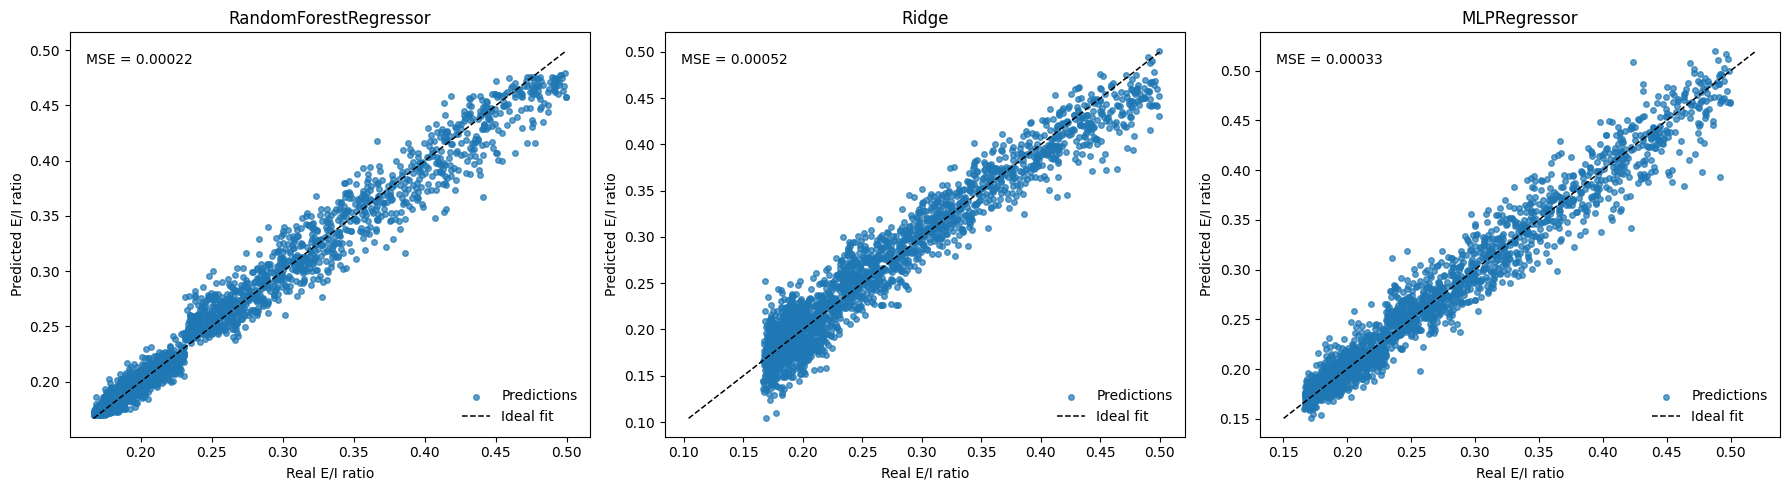


MSE ranking (best to worst):
- RandomForestRegressor: 0.00022
- MLPRegressor: 0.00033
- Ridge: 0.00052


In [5]:
print("[5/6] Plotting model comparison...")
model_names = list(results.keys())

fig, axes = plt.subplots(1, len(model_names), figsize=(6 * len(model_names), 5), squeeze=False)
axes = axes.ravel()

for ax, model_name in zip(axes, model_names):
    y_pred = results[model_name]["y_pred"]
    mse = results[model_name]["mse"]

    ax.scatter(y_test, y_pred, s=16, alpha=0.7, label="Predictions")
    lo = float(min(np.min(y_test), np.min(y_pred)))
    hi = float(max(np.max(y_test), np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.1, label="Ideal fit")

    ax.set_xlabel("Real E/I ratio")
    ax.set_ylabel("Predicted E/I ratio")
    ax.set_title(model_name)
    ax.text(0.03, 0.95, f"MSE = {mse:.5f}", transform=ax.transAxes, va="top", ha="left")
    ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

# Also print a compact ranking
ranking = sorted(((m, results[m]["mse"]) for m in model_names), key=lambda x: x[1])
print("\nMSE ranking (best to worst):")
for name, mse in ranking:
    print(f"- {name}: {mse:.5f}")
